In [1]:
import pandas as pd
import numpy as numpy
import sklearn
import os
import joblib
import pickle
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df  = pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51586,45023,-2.943382,-2.332451,2.568959,0.747114,2.083550,-1.319267,-1.837967,0.421285,0.347715,...,-0.013848,-0.091317,-0.268974,0.069693,0.202920,0.356930,-0.006093,0.268288,26.24,0.0
51587,45024,-1.278283,-3.726046,-0.902718,2.796542,-1.750987,0.199763,1.223412,-0.106145,0.793279,...,0.664178,-0.592258,-1.141974,0.322687,0.081328,-0.354449,-0.150956,0.269036,1233.16,0.0
51588,45024,-0.852261,0.886192,-0.378032,-1.142044,1.880941,3.505875,-0.403582,1.365218,-0.369193,...,0.091829,0.066337,-0.055970,1.027545,-0.327900,0.255778,0.132317,0.133329,28.98,0.0
51589,45024,-0.447740,0.775759,1.586053,0.227702,-0.270962,-0.539013,0.488655,0.071070,0.308739,...,-0.033903,0.202157,-0.180777,0.424592,-0.172455,0.365861,0.353120,0.198239,3.99,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51591 entries, 0 to 51590
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    51591 non-null  int64  
 1   V1      51591 non-null  float64
 2   V2      51591 non-null  float64
 3   V3      51591 non-null  float64
 4   V4      51591 non-null  float64
 5   V5      51591 non-null  float64
 6   V6      51591 non-null  float64
 7   V7      51591 non-null  float64
 8   V8      51591 non-null  float64
 9   V9      51591 non-null  float64
 10  V10     51591 non-null  float64
 11  V11     51590 non-null  float64
 12  V12     51590 non-null  float64
 13  V13     51590 non-null  float64
 14  V14     51590 non-null  float64
 15  V15     51590 non-null  float64
 16  V16     51590 non-null  float64
 17  V17     51590 non-null  float64
 18  V18     51590 non-null  float64
 19  V19     51590 non-null  float64
 20  V20     51590 non-null  float64
 21  V21     51590 non-null  float64
 22

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,...,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000
mean,29408.888120,-0.244221,0.003887,0.691974,0.183611,-0.259039,0.104715,-0.120474,0.054468,0.108449,...,-0.028862,-0.106634,-0.039418,0.007995,0.135556,0.020305,0.004140,0.003987,94.014363,0.002908
std,13196.047307,1.887998,1.641193,1.498371,1.398830,1.413486,1.312673,1.278442,1.216566,1.208872,...,0.732046,0.636907,0.592622,0.595768,0.438858,0.500884,0.389621,0.332373,253.518524,0.053844
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.577118,-8.567638,-9.617915,0.000000,0.000000
25%,22655.500000,-0.993823,-0.570329,0.215237,-0.723584,-0.871680,-0.634868,-0.606774,-0.146407,-0.622868,...,-0.230767,-0.528352,-0.178719,-0.322127,-0.128074,-0.330665,-0.063502,-0.006740,7.680000,0.000000
50%,33767.000000,-0.246892,0.075692,0.793662,0.190588,-0.290140,-0.150447,-0.077622,0.059086,-0.000482,...,-0.067054,-0.081866,-0.051550,0.062606,0.174933,-0.072844,0.008875,0.022241,25.345000,0.000000
75%,39498.000000,1.154831,0.731302,1.429386,1.066994,0.282184,0.495847,0.424977,0.333436,0.800723,...,0.108996,0.307826,0.078873,0.401672,0.421984,0.299365,0.083277,0.076230,86.160000,0.000000
max,45026.000000,1.960497,18.183626,4.101716,16.491217,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,12910.930000,1.000000


In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
df.duplicated().sum()

np.int64(226)

In [8]:
df.drop_duplicates()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51586,45023,-2.943382,-2.332451,2.568959,0.747114,2.083550,-1.319267,-1.837967,0.421285,0.347715,...,-0.013848,-0.091317,-0.268974,0.069693,0.202920,0.356930,-0.006093,0.268288,26.24,0.0
51587,45024,-1.278283,-3.726046,-0.902718,2.796542,-1.750987,0.199763,1.223412,-0.106145,0.793279,...,0.664178,-0.592258,-1.141974,0.322687,0.081328,-0.354449,-0.150956,0.269036,1233.16,0.0
51588,45024,-0.852261,0.886192,-0.378032,-1.142044,1.880941,3.505875,-0.403582,1.365218,-0.369193,...,0.091829,0.066337,-0.055970,1.027545,-0.327900,0.255778,0.132317,0.133329,28.98,0.0
51589,45024,-0.447740,0.775759,1.586053,0.227702,-0.270962,-0.539013,0.488655,0.071070,0.308739,...,-0.033903,0.202157,-0.180777,0.424592,-0.172455,0.365861,0.353120,0.198239,3.99,0.0


In [9]:
df.value_counts()

Time   V1         V2         V3         V4         V5         V6         V7         V8         V9         V10        V11        V12        V13        V14        V15        V16        V17        V18        V19        V20        V21        V22        V23        V24        V25       V26        V27        V28        Amount  Class
43153  -2.086016   2.203265   1.654339   2.941050  -1.683045   0.529728  -1.352162   1.793449  -0.723686   0.600365  -0.982212  -0.551636  -1.337000   0.834403   1.251862   0.033455   1.067978   0.160510   0.213087   0.079002   0.216444   0.567241  -0.035345   0.370201  0.157378   0.440341   0.210230   0.090558  0.76    0.0      9
29150   1.218702   0.177978   0.307746   1.131989  -0.196770  -0.403596   0.065584  -0.094974   0.358942  -0.106009  -1.101184   0.118125  -0.169731   0.130161   0.284551   0.010156  -0.376658  -0.257847   0.126905  -0.113694  -0.236935  -0.605319  -0.059527  -0.167249  0.591082  -0.481346   0.024247   0.022717  22.55   0.0      4
31804  -1.783888   1.245670   2.097173   1.031059  -0.793755   0.566460  -0.403512   0.625924   0.627739  -0.124831  -1.036371  -0.111653  -1.024604  -0.264647   0.194921  -0.813251   0.703947  -0.396750   0.589646  -0.264628  -0.054154  -0.029875  -0.094100   0.056197  0.116731  -0.403204  -1.117816  -0.466715  1.00    0.0      4
1548   -1.559446   1.425546   0.812589  -1.129381   0.507528   0.183507   0.654304   0.088059   0.480018   0.547216   0.066070   1.065234   0.982424  -0.609124  -1.381521   0.189597  -0.901688   0.025998   0.560580   0.451195  -0.283995  -0.413642  -0.234995  -0.789509  0.324851   0.419737   0.329608   0.351346  5.00    0.0      4
24050   0.783460  -0.766538   1.331255   1.812482  -0.929991   1.318111  -0.979965   0.472786   2.619051  -0.585481   1.053027  -1.765809   0.328310   1.034281  -2.276501  -0.441464   0.922500   0.463104  -0.140250  -0.002170   0.027365   0.410787  -0.294227  -0.325263  0.518533  -0.140764   0.042981   0.031839  150.00  0.0      4
                                                                                                                                                                                                                                                                                                                                          ..
28515  -0.168300   0.879467  -0.572700  -0.345212   3.136936   3.264143   0.712733   0.460367  -0.818549   0.204106  -0.190375  -0.424611  -0.164746   0.440764   1.012922  -0.357342  -0.677153   0.315576   0.931582   0.155247   0.044611   0.160078  -0.278971   1.013789  0.025695  -0.328249  -0.147690  -0.070130  1.49    0.0      1
        1.226643   0.101988  -0.087072   0.111524  -0.281992  -1.356027   0.469050  -0.371725  -0.153672  -0.145105  -0.143505   0.320964   0.149313   0.452515   0.776253   0.028739  -0.177867  -1.004746   0.264953   0.019692  -0.355100  -1.153663   0.109793   0.420318  0.197932   0.699218  -0.114861   0.007583  50.40   0.0      1
28516   1.132642   0.337160   0.937185   2.326148  -0.331057   0.196819  -0.360145   0.184082  -0.621987   0.853074   0.722693   0.210141  -0.346240   0.335204   0.136237   1.248006  -1.105711   0.758111  -0.804075  -0.133759   0.169129   0.409255  -0.111507  -0.014710  0.432768   0.101513   0.004705   0.016259  10.62   0.0      1
        1.137418  -0.479095   0.892020   0.171813  -0.930779  -0.065570  -0.521457   0.015105   1.087841  -0.505774  -1.074373   0.925220   1.031459  -0.763262  -0.365446  -0.013149  -0.089049  -0.583685   0.628488   0.114993  -0.221117  -0.454646  -0.043240  -0.011370  0.214130   0.964395  -0.038734   0.021180  65.26   0.0      1
28508   1.192997   0.102210   0.817157   2.382114   0.163449   1.725480  -0.682871   0.407522   0.173229   0.527510  -1.042315   0.955290   1.051538  -0.821760  -2.165861   0.685466  -0.930018   0.631747   0.368413  -0.059857  -0.030198   0.294977  -0.366065  -1.317048  0.850381   0.299455   0.048929   0.001316  0.00    0.0      1
Name: cou

In [10]:
df['Class'].value_counts()

,count
Class,
0.0,51440
1.0,150


In [12]:
from imblearn.over_sampling import SMOTE

# Drop rows with NaN values in the 'Class' column before proceeding
df_cleaned = df.dropna(subset=['Class'])

# Separate features (X) and target (y) from the cleaned DataFrame
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

print("Before OverSampling, counts of label '1': {}".format(sum(y == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y == 0)))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After OverSampling, counts of label '1': {}".format(sum(y_resampled == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_resampled == 0)))

Before OverSampling, counts of label '1': 150
Before OverSampling, counts of label '0': 51440 

After OverSampling, counts of label '1': 51440
After OverSampling, counts of label '0': 51440


In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Initialize the scaler
sc = StandardScaler()

# 3. Fit and transform all features
# We wrap it in a pd.DataFrame to keep the column names
X_scaled = pd.DataFrame(sc.fit_transform(X), columns=X.columns)

# 4. (Optional) Combine them back into a single dataframe
# We use reset_index(drop=True) to make sure the indices align properly,
# especially if you dropped duplicates earlier!
df_scaled = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

# View the scaled dataset
display(df_scaled.head())


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.228635,-0.590889,-0.046715,1.230930,0.853968,-0.056090,0.272479,0.281652,0.036357,0.211222,...,0.014419,0.603660,-0.119902,0.098921,-0.015988,-0.418105,0.332168,-0.075337,0.219338,0.0
1,-2.228635,0.760643,0.159802,-0.350714,0.189119,0.225726,-0.142516,0.032595,0.025181,-0.301005,...,-0.268993,-0.835353,0.237432,-0.583859,0.072039,0.210808,-0.033682,0.032306,-0.360231,0.0
2,-2.228559,-0.590120,-0.818955,0.721614,0.140239,-0.172737,1.291868,0.713324,0.158816,-1.342672,...,0.378204,1.379042,1.601087,-1.170392,-1.055471,-0.318244,-0.152695,-0.191770,1.122791,0.0
3,-2.228559,-0.382446,-0.115230,0.734818,-0.748420,0.175971,0.870361,0.280096,0.265477,-1.237093,...,-0.108517,0.175707,-0.254638,-1.986647,1.166265,-0.483618,0.150360,0.172913,0.116307,0.0
4,-2.228483,-0.484122,0.532453,0.571789,0.156863,-0.104816,-0.006699,0.558040,-0.267149,0.586743,...,0.026544,1.420806,-0.165436,0.223700,-0.778313,0.962281,0.552548,0.635337,-0.094765,0.0


In [14]:
import pandas as pd
import numpy as np

# 1. Separate features (everything except 'Class')
features = df_scaled.drop('Class', axis=1)

# 2. Calculate Skewness and Kurtosis
skewness = features.skew()
kurtosis = features.kurtosis()

# 3. Calculate Outliers using the IQR (Interquartile Range) Method
outlier_counts = {}

for col in features.columns:
    Q1 = features[col].quantile(0.25)
    Q3 = features[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count how many values fall outside the lower and upper bounds
    outliers = ((features[col] < lower_bound) | (features[col] > upper_bound)).sum()
    outlier_counts[col] = outliers

# 4. Combine results into a clean summary DataFrame
summary_df = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'Outlier Count (IQR)': pd.Series(outlier_counts)
})

# Display the summary table
display(summary_df)


,Skewness,Kurtosis,Outlier Count (IQR)
Time,-0.941076,-0.367714,0
V1,-4.408523,50.794779,1395
V2,-4.710806,132.888593,2792
V3,-6.418442,89.082065,1763
V4,0.477475,2.899002,609
V5,-1.416303,75.549220,3151
V6,0.981261,16.347643,4366
V7,-2.014812,92.812222,1818
V8,-5.682197,154.135297,4791
V9,0.498264,3.216268,1294


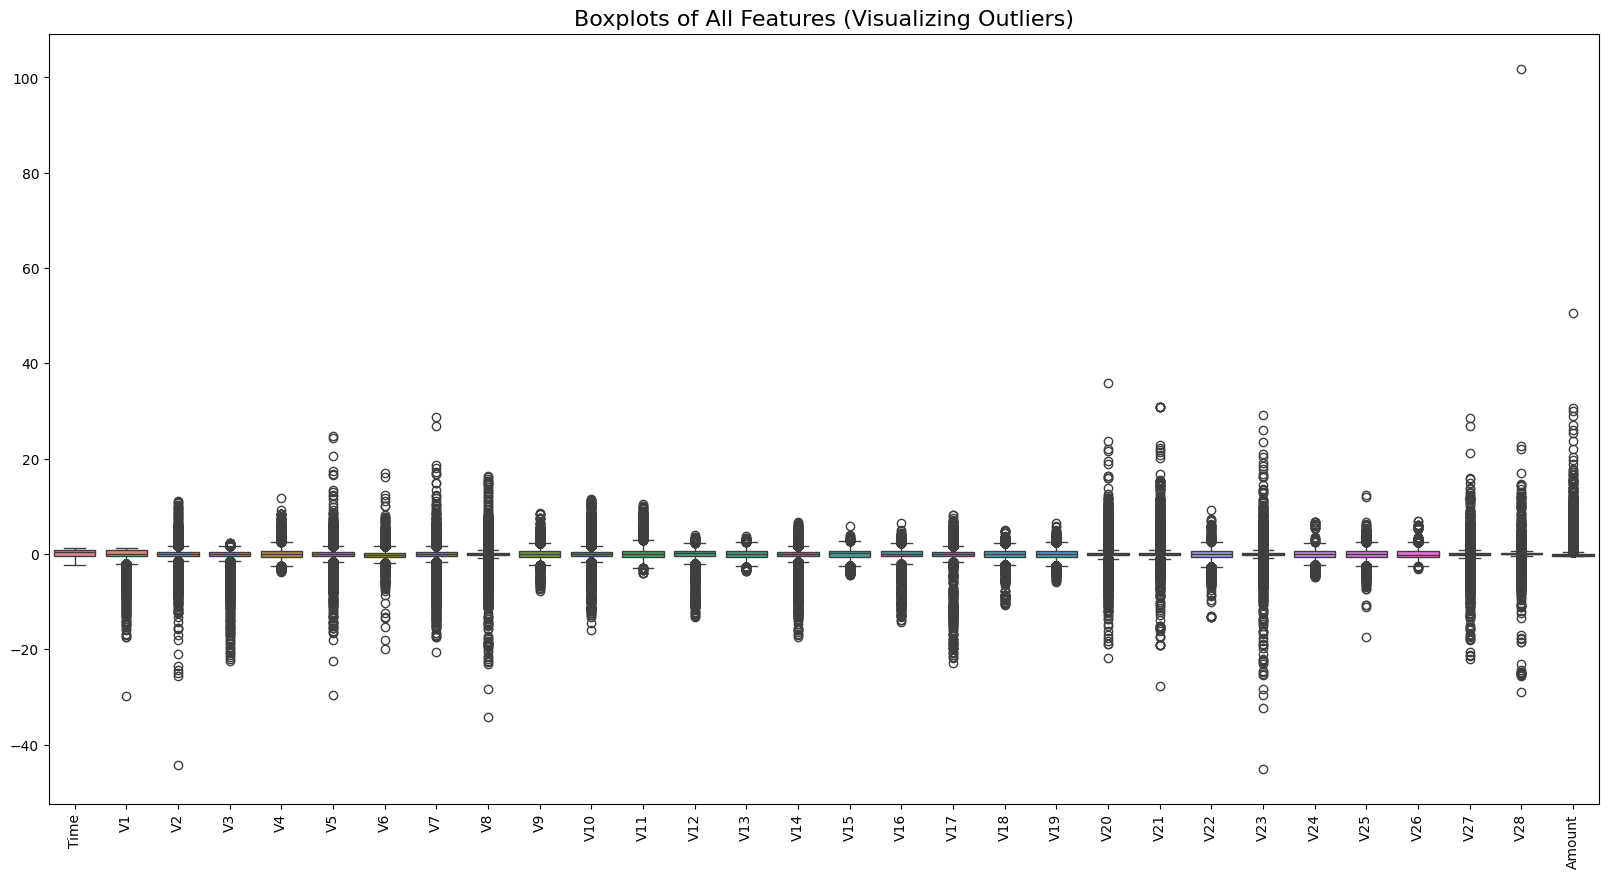

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10))

# Plot boxplots for all features
sns.boxplot(data=features)

plt.xticks(rotation=90)
plt.title("Boxplots of All Features (Visualizing Outliers)", fontsize=16)
plt.show()


In [16]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

X = df_scaled.drop('Class', axis=1)
y = df['Class']

# Initialize RobustScaler
rs = RobustScaler()

# Transform all features
X_robust = pd.DataFrame(rs.fit_transform(X), columns=X.columns)

# Re-combine
df_robust = pd.concat([X_robust, y.reset_index(drop=True)], axis=1)

display(df_robust.head())
df_robust = df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.004869,-0.517959,-0.114067,1.435313,0.663231,-0.041756,0.541989,0.307458,0.082551,0.255880,...,0.143475,0.430176,-0.228749,0.005972,-0.084344,-0.184548,0.849467,-0.521804,1.583524,0.0
1,-2.004869,0.669605,0.146323,-0.516560,0.143845,0.303466,0.060215,-0.001145,0.054216,-0.179085,...,-0.467152,-0.665894,0.593336,-0.556028,-0.014113,0.315443,-0.121666,-0.090596,-0.288672,0.0
2,-2.004809,-0.517283,-1.087755,0.806777,0.105659,-0.184647,1.725409,0.842338,0.393023,-1.063629,...,0.927270,1.020770,3.730573,-1.038806,-0.913677,-0.105158,-0.437582,-0.988225,4.501975,0.0
3,-2.004809,-0.334805,-0.200455,0.823071,-0.588570,0.242517,1.236076,0.305530,0.663444,-0.973975,...,-0.121397,0.104212,-0.538723,-1.710670,0.858896,-0.236631,0.366865,0.472663,1.250701,0.0
4,-2.004750,-0.424145,0.616184,0.621881,0.118646,-0.101444,0.217887,0.649927,-0.686930,0.574759,...,0.169599,1.052580,-0.333505,0.108679,-0.692551,0.912871,1.434456,2.325093,0.568871,0.0


In [17]:
# Create a new, balanced dataframe by combining the resampled features and target
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='Class')], axis=1)

# Now check the value counts on the NEW dataframe
print(df_balanced['Class'].value_counts())


Class
0.0    51440
1.0    51440
Name: count, dtype: int64


In [18]:
# The .round(3) makes the numbers much easier to read
display(df_balanced.describe().round(3))


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,...,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.0
mean,28286.447,-4.107,2.865,-5.062,3.115,-3.110,-1.131,-4.284,2.047,-1.797,...,0.459,-0.167,-0.145,-0.042,0.206,0.089,0.309,0.028,86.756,0.5
std,13076.323,7.116,4.199,8.258,3.579,5.394,1.807,6.189,4.416,2.660,...,1.150,0.728,0.964,0.553,0.717,0.431,0.886,0.483,210.281,0.5
min,0.000,-56.408,-72.716,-32.965,-5.173,-42.148,-26.161,-26.548,-41.485,-9.284,...,-20.262,-8.594,-26.751,-2.837,-7.496,-1.577,-8.568,-9.618,0.000,0.0
25%,17930.000,-4.602,0.046,-7.974,0.169,-4.157,-2.460,-6.958,-0.056,-3.649,...,-0.150,-0.565,-0.307,-0.339,-0.165,-0.224,-0.039,-0.022,2.670,0.0
50%,31994.000,-1.174,1.328,-1.058,2.430,-0.909,-0.896,-1.045,0.347,-1.029,...,0.177,-0.099,-0.079,0.039,0.164,0.058,0.095,0.046,24.500,0.5
75%,40562.000,0.601,4.752,0.820,6.107,0.037,-0.062,0.015,1.778,0.099,...,1.231,0.308,0.098,0.355,0.534,0.392,0.708,0.278,99.990,1.0
max,45024.000,1.960,18.184,4.102,16.491,34.802,22.529,36.677,20.007,10.393,...,22.615,5.806,17.298,4.014,5.525,3.517,11.136,33.848,12910.930,1.0


In [22]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Drop the 'Time' column as it's not useful
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)

# Drop rows with NaN values in the 'Class' column before proceeding
df = df.dropna(subset=['Class']).copy() # Added .copy() here

# 2. Standardize 'Amount' using RobustScaler (best for fraud data)
rs = RobustScaler()
df['Amount'] = rs.fit_transform(df[['Amount']])

print("--- Data Standardized Successfully ---")

# 3. Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Apply SMOTE to fix Class Imbalance
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("--- Class Imbalance Fixed with SMOTE ---")

# 5. Bring it all together into a final, clean DataFrame!
df_final = pd.concat([pd.DataFrame(X_balanced, columns=X.columns), pd.Series(y_balanced, name='Class')], axis=1)

# Now let's print the mean of our final dataset to prove it worked
display(df_final.describe().round(3))

--- Data Standardized Successfully ---
--- Class Imbalance Fixed with SMOTE ---


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,...,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.0
mean,-3.860,2.725,-4.743,3.036,-2.936,-1.076,-4.055,1.916,-1.756,-3.778,...,0.452,-0.159,-0.125,-0.036,0.211,0.089,0.306,0.024,0.778,0.5
std,7.055,4.181,8.257,3.618,5.351,1.811,6.231,4.342,2.723,4.926,...,1.177,0.724,0.928,0.559,0.712,0.438,0.906,0.494,2.743,0.5
min,-56.408,-72.716,-32.965,-5.173,-42.148,-26.161,-26.548,-41.485,-9.284,-18.271,...,-20.262,-8.594,-26.751,-2.837,-7.496,-1.577,-8.568,-9.618,-0.323,0.0
25%,-4.299,0.024,-6.841,0.161,-3.563,-2.449,-6.458,-0.067,-3.687,-7.118,...,-0.166,-0.562,-0.296,-0.327,-0.159,-0.225,-0.035,-0.013,-0.297,0.0
50%,-1.034,1.153,-0.663,2.084,-0.896,-0.797,-0.823,0.288,-0.872,-1.178,...,0.154,-0.092,-0.072,0.052,0.157,0.046,0.084,0.048,-0.038,0.5
75%,0.764,4.422,0.867,6.112,0.122,-0.027,0.094,1.538,0.167,-0.076,...,1.213,0.317,0.098,0.364,0.527,0.411,0.608,0.243,0.951,1.0
max,1.960,18.184,4.102,16.491,34.802,22.529,36.677,20.007,10.393,13.198,...,22.615,5.806,17.298,4.014,5.525,3.517,11.136,33.848,164.189,1.0


In [21]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. Separate features and target from your newly balanced data
X = df_final.drop('Class', axis=1)
y = df_final['Class']

# 2. Initialize the Power Transformer (Yeo-Johnson is the best method here)
pt = PowerTransformer(method='yeo-johnson')

# 3. Fit and transform the features
X_transformed = pd.DataFrame(pt.fit_transform(X), columns=X.columns)

# 4. Re-combine with the target variable
df_ready_for_ml = pd.concat([X_transformed, y], axis=1)

print("Skewness and Kurtosis fixed!")
display(df_ready_for_ml.head())


Skewness and Kurtosis fixed!


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.113384,-0.626819,2.029216,-0.281024,0.345996,0.857014,0.679082,-0.344715,0.731975,0.751209,...,-0.378542,0.561438,-0.055985,0.084364,-0.124869,-0.599630,-0.222296,-0.107860,1.286565,0.0
1,1.368127,-0.523294,0.377306,-0.597499,0.477586,0.564057,0.565049,-0.349564,0.426261,0.652770,...,-0.560282,-0.716166,0.217289,-0.628629,-0.070618,0.154200,-0.378066,-0.035195,-1.007078,0.0
2,-0.113004,-1.068102,1.365130,-0.623390,0.296716,1.560551,0.911789,-0.292920,-0.076154,0.799501,...,-0.148976,1.391216,1.406473,-1.159620,-0.760224,-0.474150,-0.428238,-0.186191,1.761658,0.0
3,-0.002118,-0.662757,1.380855,-1.199841,0.452795,1.271750,0.678320,-0.249597,-0.029754,0.694208,...,-0.457073,0.145542,-0.154575,-1.815695,0.608671,-0.683080,-0.299990,0.060084,1.154203,0.0
4,-0.058589,-0.350404,1.192434,-0.614533,0.325103,0.660535,0.823373,-0.484594,0.987881,1.052150,...,-0.370823,1.438375,-0.089553,0.229416,-0.591725,0.955855,-0.127410,0.376143,0.707863,0.0


Class distribution:
 Class
0.0    51440
1.0    51440
Name: count, dtype: int64
Training: (82304, 29) | Testing: (20576, 29)

--- 5-Fold Cross-Validation (F1-Score) ---
Logistic Regression: 0.9789 (+/- 0.0008)
Random Forest: 0.9998 (+/- 0.0001)
XGBoost: 0.9998 (+/- 0.0001)

--- Final Test Set Results ---

Logistic Regression:

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     10288
         1.0       0.99      0.97      0.98     10288

    accuracy                           0.98     20576
   macro avg       0.98      0.98      0.98     20576
weighted avg       0.98      0.98      0.98     20576



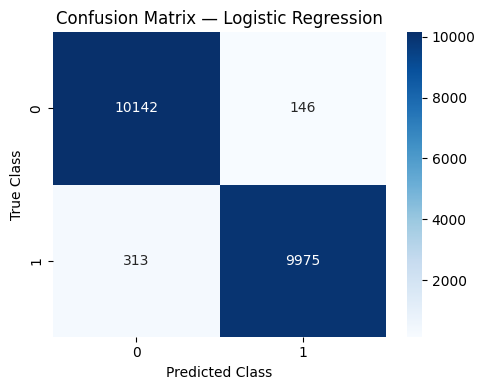


Random Forest:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10288
         1.0       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576



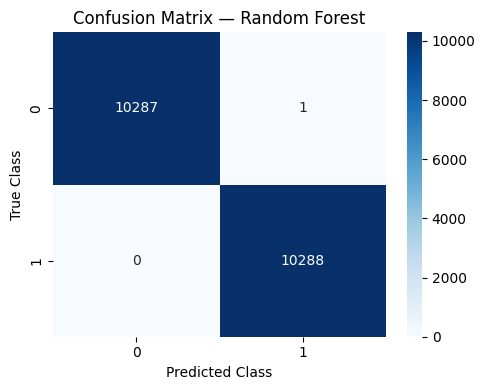


XGBoost:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10288
         1.0       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576



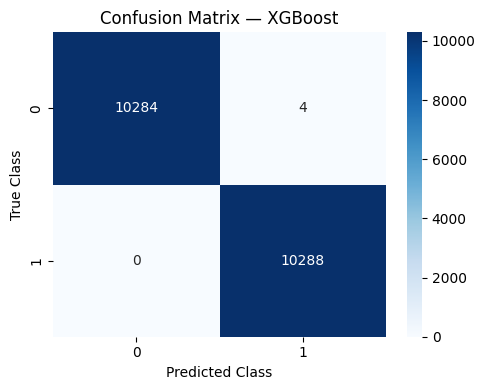

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Sanity check on balance
X = df_final.drop('Class', axis=1)
y = df_final['Class']
print("Class distribution:\n", y.value_counts())

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training: {X_train.shape} | Testing: {X_test.shape}\n")

# 3. Models — LR wrapped in pipeline for scaling
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1, verbosity=0)
}

# 4. Cross-Validation with F1 (correct metric for fraud)
print("--- 5-Fold Cross-Validation (F1-Score) ---")
for name, model in models.items():
    try:
        # Use n_jobs=1 to avoid compatibility issues
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=1)
        print(f"{name}: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
    except Exception as e:
        print(f"{name}: Error in cross-validation - {str(e)[:100]}")

# 5. Final evaluation on all models
print("\n--- Final Test Set Results ---")
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"\n{'='*40}\n{name}:\n")
        print(classification_report(y_test, y_pred))

        # Confusion matrix per model
        plt.figure(figsize=(5, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix — {name}')
        plt.ylabel('True Class')
        plt.xlabel('Predicted Class')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"{name}: Error during training/evaluation - {str(e)[:100]}")


Training Isolation Forest on the raw imbalanced data...

--- Unsupervised Isolation Forest Results ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51440
         1.0       0.66      0.39      0.49       150

    accuracy                           1.00     51590
   macro avg       0.83      0.69      0.74     51590
weighted avg       1.00      1.00      1.00     51590



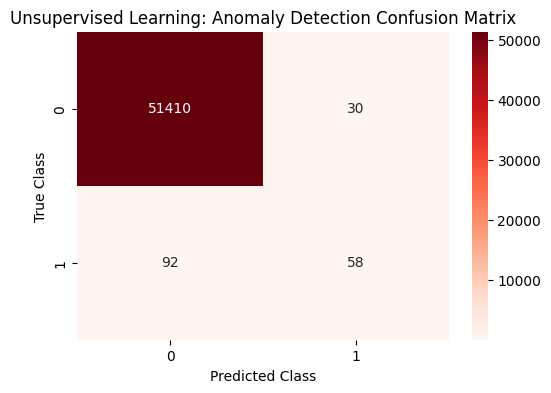

In [25]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab the ORIGINAL, imbalanced dataset
imbalanced = df.drop('Class', axis=1)
y_imbalanced = df['Class']

# 2. Initialize Isolation Forest
# Contamination is set to ~0.17% (the true expected ratio of fraud in the raw dataset)
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42, n_jobs=-1)

# 3. Fit and Predict
print("Training Isolation Forest on the raw imbalanced data...")
y_pred_iso = iso_forest.fit_predict(imbalanced)

# 4. Map the predictions
# Isolation Forest tags anomalies as -1, and normal transactions as 1.
# We flip it to 1 (Fraud) and 0 (Normal) to match our actual data.
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

# 5. Evaluate the Anomaly Detector
print("\n--- Unsupervised Isolation Forest Results ---")
print(classification_report(y_imbalanced, y_pred_iso))

# Plot Confusion Matrix for Isolation forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_imbalanced, y_pred_iso), annot=True, fmt='d', cmap='Reds')
plt.title('Unsupervised Learning: Anomaly Detection Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

 Dataset Summary
Class
Legit    51440
Fraud    51440
Name: count, dtype: int64

Fraud rate: 50.000%

Train: (82304, 29)  |  Test: (20576, 29)


>>> MODEL 1: XGBoost + Random Oversampling
After oversampling → {0.0: 41152, 1.0: 41152}

  XGBoost + RandomOverSampler
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9998
  AUC-ROC  : 1.0000
  Avg Prec : 1.0000


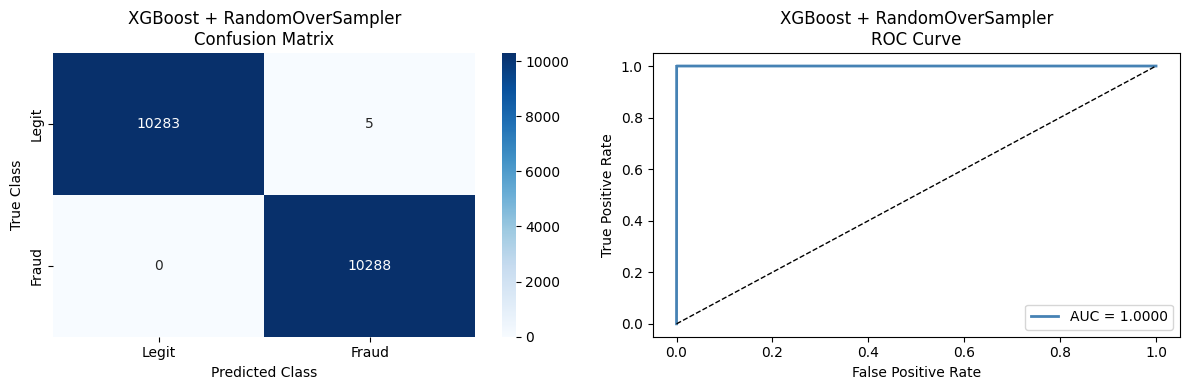



>>> MODEL 2: Random Forest + SMOTE

  Random Forest + SMOTE
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9999
  AUC-ROC  : 1.0000
  Avg Prec : 1.0000


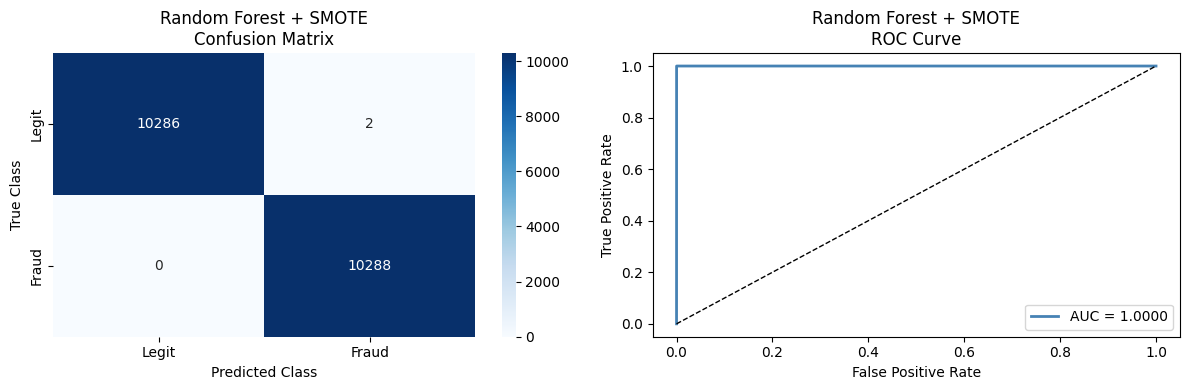

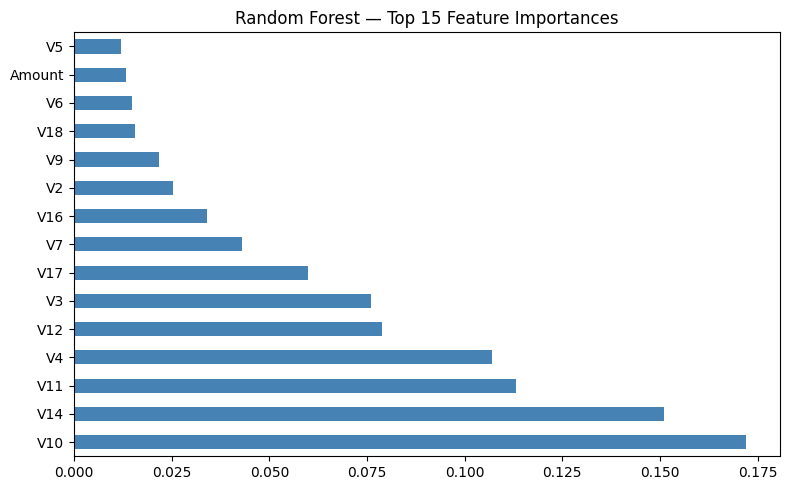



>>> MODEL 3: Stacking Ensemble (RF + XGB + CatBoost + SVM + DT → LR)

  Stacking Ensemble
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9999
  AUC-ROC  : 1.0000
  Avg Prec : 1.0000


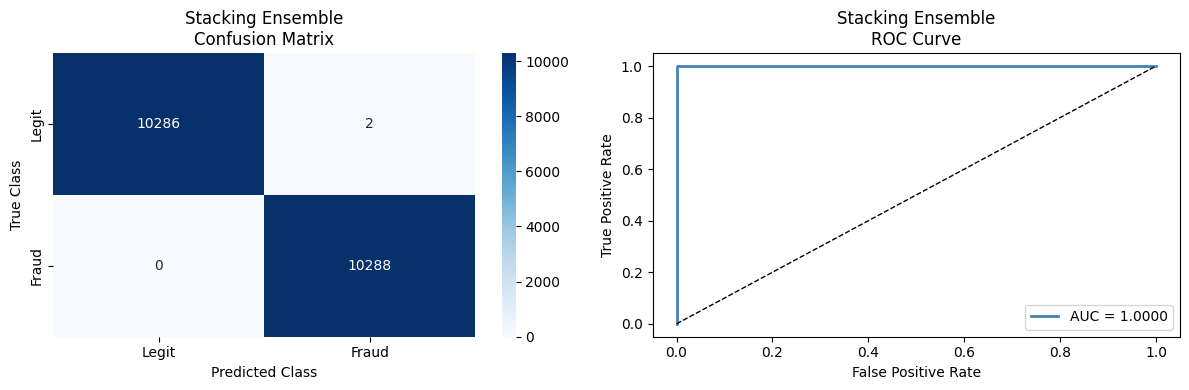



>>> MODEL 4: LSTM (Deep Learning)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        80,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,673 (518.25 KB)

 Trainable params: 132,545 (517.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9645 - auc: 0.9929 - loss: 0.1056 - val_accuracy: 0.9850 - val_auc: 0.9990 - val_loss: 0.3289 - learning_rate: 0.0010
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9876 - auc: 0.9988 - loss: 0.0367 - val_accuracy: 0.9927 - val_auc: 0.9996 - val_loss: 0.1199 - learning_rate: 0.0010
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9918 - auc: 0.9993 - loss: 0.0240 - val_accuracy: 0.9964 - val_auc: 0.9998 - val_loss: 0.0313 - learning_rate: 0.0010
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9948 - auc: 0.9996 - loss: 0.0170 - val_accuracy: 0.9974 - val_auc: 0.9997 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9962 - auc: 0.9996 - loss: 0.0130 - val_accuracy: 0.9986 - val_auc: 1.0000 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9972 - a

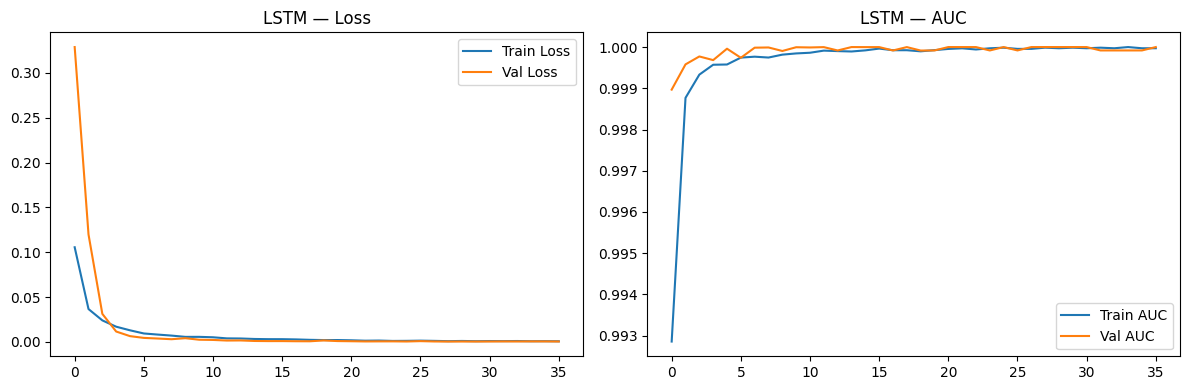

643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

  LSTM (Deep Learning)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9994
  AUC-ROC  : 0.9999
  Avg Prec : 0.9999


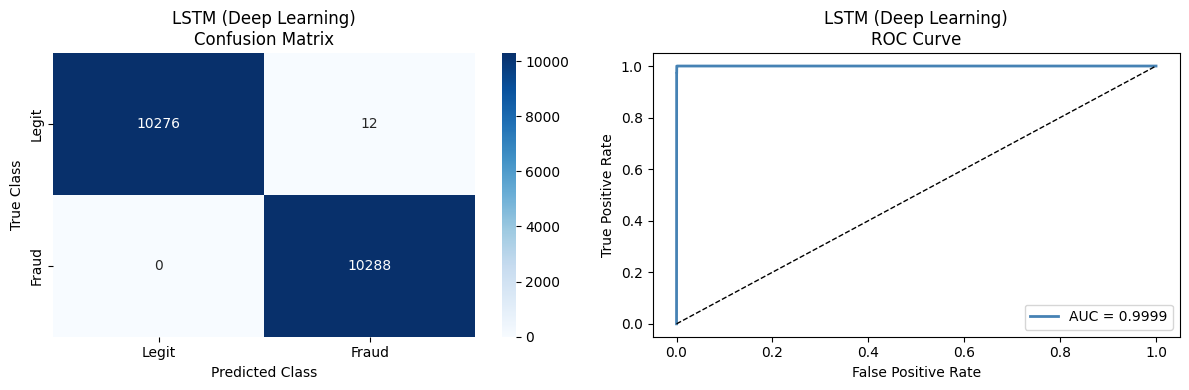



  FINAL MODEL COMPARISON
                      model     f1    auc
      Random Forest + SMOTE 0.9999 1.0000
          Stacking Ensemble 0.9999 1.0000
XGBoost + RandomOverSampler 0.9998 1.0000
       LSTM (Deep Learning) 0.9994 0.9999


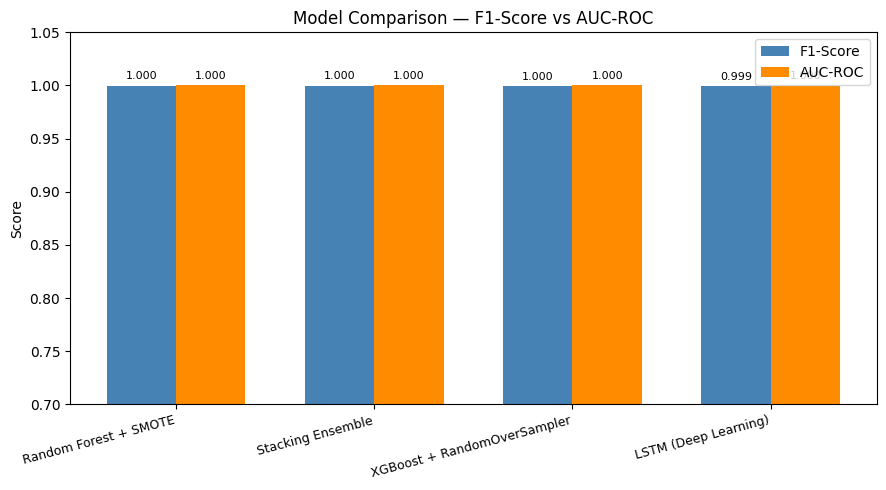


✅ All models trained and evaluated.
   Saved: *_results.png, lstm_training_curves.png, model_comparison.png


In [28]:
!pip install XGBoost
!pip install CatBoost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score
)

# Classical ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Boosting
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    BatchNormalization, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# ─────────────────────────────────────────────
#  SECTION 1 — LOAD & PREPARE DATA
# ─────────────────────────────────────────────
# Use the already processed and balanced DataFrame from previous steps
df = df_ready_for_ml

print("=" * 60)
print(" Dataset Summary")
print("=" * 60)
print(df['Class'].value_counts().rename({0: 'Legit', 1: 'Fraud'}))
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")

# Features & target
X = df.drop('Class', axis=1)
y = df['Class']

# Scaling of Amount and Time was already handled in previous cells (df_ready_for_ml is already scaled)
# This section is removed as it would be redundant and potentially cause errors if 'Time' column is dropped.

# Train/Test split (stratified to preserve fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")


# ─────────────────────────────────────────────
#  HELPER: Evaluation function
# ─────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Print full metrics and plot confusion matrix + ROC curve."""
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud']))

    f1  = f1_score(y_true, y_pred)
    print(f"  F1-Score : {f1:.4f}")

    if y_prob is not None:
        auc  = roc_auc_score(y_true, y_prob)
        ap   = average_precision_score(y_true, y_prob)
        print(f"  AUC-ROC  : {auc:.4f}")
        print(f"  Avg Prec : {ap:.4f}")
    else:
        auc = None

    # ── Confusion Matrix ──
    fig, axes = plt.subplots(1, 2 if auc else 1, figsize=(12 if auc else 5, 4))
    ax_cm = axes[0] if auc else axes

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax_cm.set_title(f'{name}\nConfusion Matrix')
    ax_cm.set_ylabel('True Class')
    ax_cm.set_xlabel('Predicted Class')

    # ── ROC Curve ──
    if auc:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1],[0,1],'k--', lw=1)
        axes[1].set_title(f'{name}\nROC Curve')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(f"{name.replace(' ', '_').lower()}_results.png", dpi=120)
    plt.show()
    return {'model': name, 'f1': round(f1, 4), 'auc': round(auc, 4) if auc else None}


results_summary = []


# ═══════════════════════════════════════════════════════════
#  MODEL 1 — XGBoost + Random Oversampling
#  Paper accuracy: 99.3%  |  F1: 92.43%
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 1: XGBoost + Random Oversampling")

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"After oversampling → {pd.Series(y_train_ros).value_counts().to_dict()}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,          # balanced because we oversampled
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False      # safe for older xgboost; remove if error
)
xgb_model.fit(
    X_train_ros, y_train_ros,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb  = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]
res = evaluate_model("XGBoost + RandomOverSampler", y_test, y_pred_xgb, y_prob_xgb)
results_summary.append(res)


# ═══════════════════════════════════════════════════════════
#  MODEL 2 — Random Forest + SMOTE
#  Paper accuracy: 99.95%  |  F1: 91.55%
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 2: Random Forest + SMOTE")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf  = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
res = evaluate_model("Random Forest + SMOTE", y_test, y_pred_rf, y_prob_rf)
results_summary.append(res)

# Feature importance plot
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.nlargest(15).plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=120)
plt.show()


# ═══════════════════════════════════════════════════════════
#  MODEL 3 — STACKING ENSEMBLE
#  Base: DT + RF + SVM + XGBoost + CatBoost
#  Meta: Logistic Regression
#  Paper F1: 88.14% (on real-world imbalanced, no oversampling)
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 3: Stacking Ensemble (RF + XGB + CatBoost + SVM + DT → LR)")

base_estimators = [
    ('dt',  DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(
                n_estimators=200, eval_metric='logloss',
                random_state=42, n_jobs=-1, verbosity=0
            )),
    ('cat', CatBoostClassifier(
                iterations=200, learning_rate=0.05,
                random_seed=42, verbose=0
            )),
    ('svm', SVC(kernel='rbf', probability=True, C=1.0, random_state=42)),
]

meta_learner = LogisticRegression(max_iter=1000, random_state=42, C=1.0)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Use SMOTE-balanced data for stacking
stacking_model.fit(X_train_sm, y_train_sm)

y_pred_stack = stacking_model.predict(X_test)
y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]
res = evaluate_model("Stacking Ensemble", y_test, y_pred_stack, y_prob_stack)
results_summary.append(res)


# ═══════════════════════════════════════════════════════════
#  MODEL 4 — LSTM (Deep Learning)
#  Paper accuracy: 99.2%  |  AUC: 96.3%  |  DR: 93.3%
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 4: LSTM (Deep Learning)")

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_sm.values.reshape(-1, 1, X_train_sm.shape[1])
X_test_lstm  = X_test.values.reshape(-1, 1, X_test.shape[1])

def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

lstm_model = build_lstm((1, X_train_sm.shape[1]))
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

history = lstm_model.fit(
    X_train_lstm, y_train_sm.values,
    epochs=50,
    batch_size=512,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('LSTM — AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=120)
plt.show()

# Predict
y_prob_lstm = lstm_model.predict(X_test_lstm).ravel()
threshold   = 0.5   # tune this for higher recall
y_pred_lstm = (y_prob_lstm >= threshold).astype(int)

res = evaluate_model("LSTM (Deep Learning)", y_test, y_pred_lstm, y_prob_lstm)
results_summary.append(res)


# ═══════════════════════════════════════════════════════════
#  SECTION 5 — FINAL COMPARISON TABLE
# ═══════════════════════════════════════════════════════════
print("\n\n" + "=" * 60)
print("  FINAL MODEL COMPARISON")
print("=" * 60)

df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values('f1', ascending=False)
print(df_results.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['f1'],  width, label='F1-Score',  color='steelblue')
bars2 = ax.bar(x + width/2, df_results['auc'], width, label='AUC-ROC',   color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(df_results['model'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — F1-Score vs AUC-ROC')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()

print("\n✅ All models trained and evaluated.")
print("   Saved: *_results.png, lstm_training_curves.png, model_comparison.png")

In [ ]:
import joblib

# Assuming rf_model is the best performing model based on previous evaluation
# If a different model is considered 'best', replace 'rf_model' with the appropriate variable
best_model = rf_model

# Define the filename for the pickle file
model_filename = 'best_model.pkl'

# Save the model to a pickle file
joblib.dump(best_model, model_filename)

print(f"Best model (Random Forest + SMOTE) saved to {model_filename}")